## Import libraries 

In [1]:
# Import libs
import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
import matplotlib.pyplot as plt
from sliding_window import create_feature_set
from sliding_window import plot_history


# Target coordinates

In [2]:
data_target = np.load('../../extracted_pdb_all_atom_backbone_iga_antigen.npy').astype(float)[:,1:]
data_target.shape

(5006, 19764)

In [3]:
train_feat = data_target[:100,:]/240
train_feat 

array([[0.537375  , 0.196625  , 0.429625  , ..., 0.60391667, 0.34495833,
        0.54720833],
       [0.53933333, 0.19404167, 0.41033333, ..., 0.60133333, 0.34941667,
        0.541875  ],
       [0.53395833, 0.18208333, 0.40508333, ..., 0.59625   , 0.3315    ,
        0.53325   ],
       ...,
       [0.54466667, 0.208375  , 0.31579167, ..., 0.595125  , 0.25420833,
        0.49908333],
       [0.545125  , 0.21225   , 0.31445833, ..., 0.592875  , 0.25341667,
        0.49675   ],
       [0.52725   , 0.20975   , 0.31408333, ..., 0.59425   , 0.25370833,
        0.49620833]])

In [4]:
train_feat.shape

(100, 19764)

In [5]:
train_LAB_48 = create_feature_set(train_feat)
train_LAB_48.shape

(164400, 48)

In [6]:
train_LAB_48[-1,:]

array([0.63591667, 0.269875  , 0.51704167, 0.63208333, 0.2735    ,
       0.51408333, 0.62658333, 0.27058333, 0.5125    , 0.62683333,
       0.26579167, 0.51075   , 0.62170833, 0.27341667, 0.51308333,
       0.61625   , 0.27058333, 0.512     , 0.61366667, 0.27254167,
       0.50666667, 0.61329167, 0.27758333, 0.50570833, 0.61204167,
       0.26870833, 0.503     , 0.61025   , 0.269875  , 0.49725   ,
       0.604125  , 0.26779167, 0.495625  , 0.60195833, 0.26879167,
       0.49095833, 0.60170833, 0.26466667, 0.49966667, 0.59608333,
       0.26241667, 0.50008333, 0.59375   , 0.25895833, 0.49558333,
       0.59425   , 0.25370833, 0.49620833])

In [7]:
data_bb = np.load('../../data_bb.npy')
data_bb.shape

(5006, 4941)

In [8]:
train_feat = data_bb[:100,:]
train_feat.shape

(100, 4941)

In [9]:
train_feat_12 = create_feature_set(train_feat,12,3)
train_feat_12.shape

(164400, 12)

In [11]:
train_feat_12.shape[0] - train_LAB_48.shape[0]

0

In [10]:
del data_bb, data_target

In [16]:
32/2

16.0

In [21]:

def create_model_1(input_shape, num_outputs):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(256, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(16, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    #-----------------------------------------------------------------------------------

    x = tf.keras.layers.Dense(8, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(16, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)
  
    
    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model



In [22]:
# Example usage:
input_shape = (12,)  # Example input shape, adjust based on your actual data
output_num = 48  # Example number of bins, adjust based on your actual data

# Create the model
model = create_model_1(input_shape, output_num)

In [23]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_9 (Dense)             (None, 256)               3328      
                                                                 
 batch_normalization_8 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_9 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 128)               0   

In [32]:
t = 4096*2
t


8192

In [41]:

def create_model_2(input_shape, num_outputs):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(2048, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

     
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

     
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    #-----------------------------------------------------------------------------------

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)
  
    
    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model



In [42]:
# Example usage:
input_shape = (12,)  # Example input shape, adjust based on your actual data
output_num = 48  # Example number of bins, adjust based on your actual data

# Create the model
model = create_model_2(input_shape, output_num)

In [43]:
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 12)]              0         
                                                                 
 dense_35 (Dense)            (None, 2048)              26624     
                                                                 
 batch_normalization_31 (Ba  (None, 2048)              8192      
 tchNormalization)                                               
                                                                 
 dense_36 (Dense)            (None, 1024)              2098176   
                                                                 
 batch_normalization_32 (Ba  (None, 1024)              4096      
 tchNormalization)                                               
                                                                 
 dropout_27 (Dropout)        (None, 1024)              0   

In [44]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001), loss='mse',metrics=['mae',keras.metrics.RootMeanSquaredError()])


In [45]:
history = model.fit(
    train_feat_12,train_LAB_48,
    epochs =10,
    shuffle = True

)

Epoch 1/10
5138/5138 [==============================] - 88s 17ms/step - loss: 0.0262 - mae: 0.0707 - root_mean_squared_error: 0.1619
Epoch 2/10
5138/5138 [==============================] - 89s 17ms/step - loss: 0.0015 - mae: 0.0304 - root_mean_squared_error: 0.0393
Epoch 3/10
5138/5138 [==============================] - 89s 17ms/step - loss: 0.0013 - mae: 0.0278 - root_mean_squared_error: 0.0360
Epoch 4/10
5138/5138 [==============================] - 86s 17ms/step - loss: 0.0012 - mae: 0.0266 - root_mean_squared_error: 0.0345
Epoch 5/10
5138/5138 [==============================] - 84s 16ms/step - loss: 0.0011 - mae: 0.0258 - root_mean_squared_error: 0.0335
Epoch 6/10
5138/5138 [==============================] - 93s 18ms/step - loss: 0.0011 - mae: 0.0256 - root_mean_squared_error: 0.0332
Epoch 7/10
5138/5138 [==============================] - 83s 16ms/step - loss: 0.0010 - mae: 0.0250 - root_mean_squared_error: 0.0323
Epoch 8/10
5138/5138 [==============================] - 113s 22ms/ste

In [2]:
from tensorflow.keras import layers, models, callbacks, regularizers



In [3]:
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [4]:
callbacks=[reduce_lr]

1e-06

old shape: (5006, 19765)

In [8]:
data_feature1 = data_feature[0:2,:]

In [9]:
np.savetxt("foo.csv", data_feature1, delimiter=",")

In [2]:
2340*3

7020

In [ ]:
import tensorflow as tf

def create_model_LeakyRELU(input_shape, num_outputs, alpha=0.2, activation_layer=tf.keras.layers.LeakyReLU):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(2048, kernel_initializer='he_normal')(inputs)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(1024, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(512, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(256, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(256, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(128, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Dense(64, kernel_initializer='he_normal')(x)
    x = activation_layer(alpha=alpha)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    output = tf.keras.layers.Dense(num_outputs, activation='linear')(x)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    return model

# Example input shape and output number, adjust based on your actual data
input_shape = (12,)
output_num = 48

# Alpha value for LeakyReLU
alpha_value = 0.3  # You can adjust this as needed

# Create the model
model = create_model_LeakyRELU(input_shape, output_num, alpha=alpha_value)

# Compile the model with built-in RMSE and MAE metrics
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])

# Define the ModelCheckpoint callback
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',   # Path where the best model will be saved
    monitor='val_loss',         # Metric to monitor
    save_best_only=True,        # Save only the best model
    save_weights_only=False,    # Save the full model
    mode='min',                 # Minimize the monitored metric
    verbose=1                   # Verbose output when saving the model
)

# Train the model with the callback
history = model.fit(
    train_data,                 # Replace with your training data
    train_labels,               # Replace with your training labels
    validation_data=(val_data, val_labels),  # Replace with your validation data and labels
    epochs=50,                  # Number of epochs
    batch_size=32,              # Batch size
    callbacks=[checkpoint_callback]  # Add the checkpoint callback
)


In [3]:
24*3

72

In [3]:
10042/60


167.36666666666667

In [4]:
167.36666666666667/60

2.7894444444444444

In [7]:
2.8*25

70.0

In [6]:
280/24

11.666666666666666

In [8]:
24*3

72

In [20]:
number_beads= {
 'CYS':[1,[2]],
 'ALA':[0,[3]],
 'MET':[1,[2]],
 'ASP':[1,[4]],
 'ASN':[1,[3]],
 'ARG':[2,[2,4]],
 'GLN':[1,[3]],
 'GLU':[1,[4]],
 'GLY':[0,[3]],
 'HIS':[3,[1,3,3]],
 'ILE':[1,[1]],
 'LEU':[1,[1]],
 'LYS':[2,[1,4]],
 'PHE':[3,[1,1,1]],
 'PRO':[1,[1]],
 'SER':[1,[3]],
 'THR':[1,[3]],
 'TRP':[4,[1,3,1,1]],
 'TYR':[3,[1,1,3]],
 'VAL':[1,[1]]
 }

In [27]:
number_beads

{'CYS': [1, [2]],
 'ALA': [0, [3]],
 'MET': [1, [2]],
 'ASP': [1, [4]],
 'ASN': [1, [3]],
 'ARG': [2, [2, 4]],
 'GLN': [1, [3]],
 'GLU': [1, [4]],
 'GLY': [0, [3]],
 'HIS': [3, [1, 3, 3]],
 'ILE': [1, [1]],
 'LEU': [1, [1]],
 'LYS': [2, [1, 4]],
 'PHE': [3, [1, 1, 1]],
 'PRO': [1, [1]],
 'SER': [1, [3]],
 'THR': [1, [3]],
 'TRP': [4, [1, 3, 1, 1]],
 'TYR': [3, [1, 1, 3]],
 'VAL': [1, [1]]}

In [22]:
len(number_beads.keys())

20

In [25]:
no_Atoms= {
 'CYS':[2,[0]],
 'ALA':[1,[0]],
 'MET':[4,[0]],
 'ASP':[4,[0]],
 'ASN':[4,[0]],
 'ARG':[7,['0_3','3_8']],
 'GLN':[5,[0]],
 'GLU':[5,[0]],
 'GLY':[0,[0]],
 'HIS':[6,['0_2','2_4','4_6']],
 'ILE':[4,[0]],
 'LEU':[4,[0]],
 'LYS':[5,['0_3','3_5']],
 'PHE':[7,['0_3','3_5','5_7']],
 'PRO':[3,[0]],
 'SER':[2,[0]],
 'THR':[3,[0]],
 'TRP':[10,['0,1,9','2_5','7,8','5,6']],
 'TYR':[8,['0_3','3_6','6_8']],
 'VAL':[3,[0]]
 }

In [26]:
no_Atoms

{'CYS': [2, [0]],
 'ALA': [1, [0]],
 'MET': [4, [0]],
 'ASP': [4, [0]],
 'ASN': [4, [0]],
 'ARG': [7, ['0_3', '3_8']],
 'GLN': [5, [0]],
 'GLU': [5, [0]],
 'GLY': [0, [0]],
 'HIS': [6, ['0_2', '2_4', '4_6']],
 'ILE': [4, [0]],
 'LEU': [4, [0]],
 'LYS': [5, ['0_3', '3_5']],
 'PHE': [7, ['0_3', '3_5', '5_7']],
 'PRO': [3, [0]],
 'SER': [2, [0]],
 'THR': [3, [0]],
 'TRP': [10, ['0,1,9', '2_5', '7,8', '5,6']],
 'TYR': [8, ['0_3', '3_6', '6_8']],
 'VAL': [3, [0]]}

In [28]:
import re

In [35]:
filenames = ["cluster_8_SC.npy", "cluster_1_SC.npy"]

In [30]:
pattern = r"cluster_(\d+)_SC.npy"
numbers = [int(re.search(pattern, filename).group(1)) for filename in filenames]


In [42]:
filename = "cluster_99_SC.npy"


pattern = r"cluster_(\d+)_SC.npy"
number = int(re.search(pattern, cluster_file).group(1))
number

99

In [43]:
12 24 48

48

In [ ]:
sed 's/HID/HIS/g' cluster_backbone_96/frame_111190.pdb > temp.pdb
sed 's/CLEUA/LEU A/g' temp.pdb > temp2.pdb
rm $output_file
sed 's/NSERB/SER B/g' temp2.pdb > temp3.pdb
sed 's/CLEUB/LEU B/g' temp3.pdb > temp4.pdb
sed 's/NSERC/SER C/g' temp4.pdb > temp5.pdb
sed 's/CLEUC/LEU C/g' temp5.pdb > temp6.pdb
sed 's/ASH/ASP/g' temp6.pdb > temp7.pdb
sed 's/CYM/CYS/g' temp7.pdb > temp8.pdb
sed 's/HIP/HIS/g' temp8.pdb > temp9.pdb
sed 's/NSERA/SER A/g' temp9.pdb > temp10.pdb

In [44]:

(14*5)/4.8

14.583333333333334

In [45]:
14/5

2.8

In [46]:
3*4.8

14.399999999999999

1

In [50]:
1 - 7




7.0

In [54]:
73/14

5.214285714285714

In [52]:
800/80


10.0

In [53]:
75/14

5.357142857142857

In [55]:
907/30.4


29.835526315789476

In [57]:
32*2

64

In [16]:
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
with open('training_history_winS_2.json', 'r') as f:
    history_dict_2 = json.load(f)

In [4]:
with open('training_history_winS_4.json', 'r') as f:
    history_dict_4 = json.load(f)

In [5]:
with open('training_history_winS_8.json', 'r') as f:
    history_dict_8 = json.load(f)

In [77]:
with open('training_history_winS_16.json', 'r') as f:
    history_dict_16 = json.load(f)


with open('training_history_winS_32.json', 'r') as f:
    history_dict_32 = json.load(f)

with open('training_history_winS_64.json', 'r') as f:
    history_dict_64 = json.load(f)

In [78]:
def load_history(json_path, model_name):
    with open(json_path, 'r') as f:
        history = json.load(f)
    
    # Create a DataFrame from history with model name added
    df = pd.DataFrame(history)
    df['epoch'] = df.index + 1
    df = df.melt(id_vars=['epoch'], var_name='metric', value_name='value')
    df['model'] = model_name
    return df

In [80]:
model1 = load_history('training_history_winS_2.json','Win 2')
model2 = load_history('training_history_winS_4.json','Win 4')
model3 = load_history('training_history_winS_8.json','Win 8')
model4 = load_history('training_history_winS_16.json','Win 16')
model5 = load_history('training_history_winS_32.json','Win 32')
model6 = load_history('training_history_winS_64.json','Win 64')

In [82]:
model6

,epoch,metric,value,model
0,1,loss,0.002700,Win 64
1,2,loss,0.001798,Win 64
2,3,loss,0.001783,Win 64
3,4,loss,0.001773,Win 64
4,5,loss,0.001765,Win 64
...,...,...,...,...
295,46,val_root_mean_squared_error,0.142119,Win 64
296,47,val_root_mean_squared_error,0.140940,Win 64
297,48,val_root_mean_squared_error,0.140486,Win 64
298,49,val_root_mean_squared_error,0.142351,Win 64


In [86]:
# Combine all histories into one DataFrame
all_models = pd.concat([model1, model2, model3,model4,model5,model6])
# Filter to include only RMSE metrics if there are multiple types
all_models = all_models[all_models['metric'].str.contains('val_root_mean_squared_error', case=False)]

In [84]:
all_models = all_models[all_models['metric']=='root_mean_squared_error']

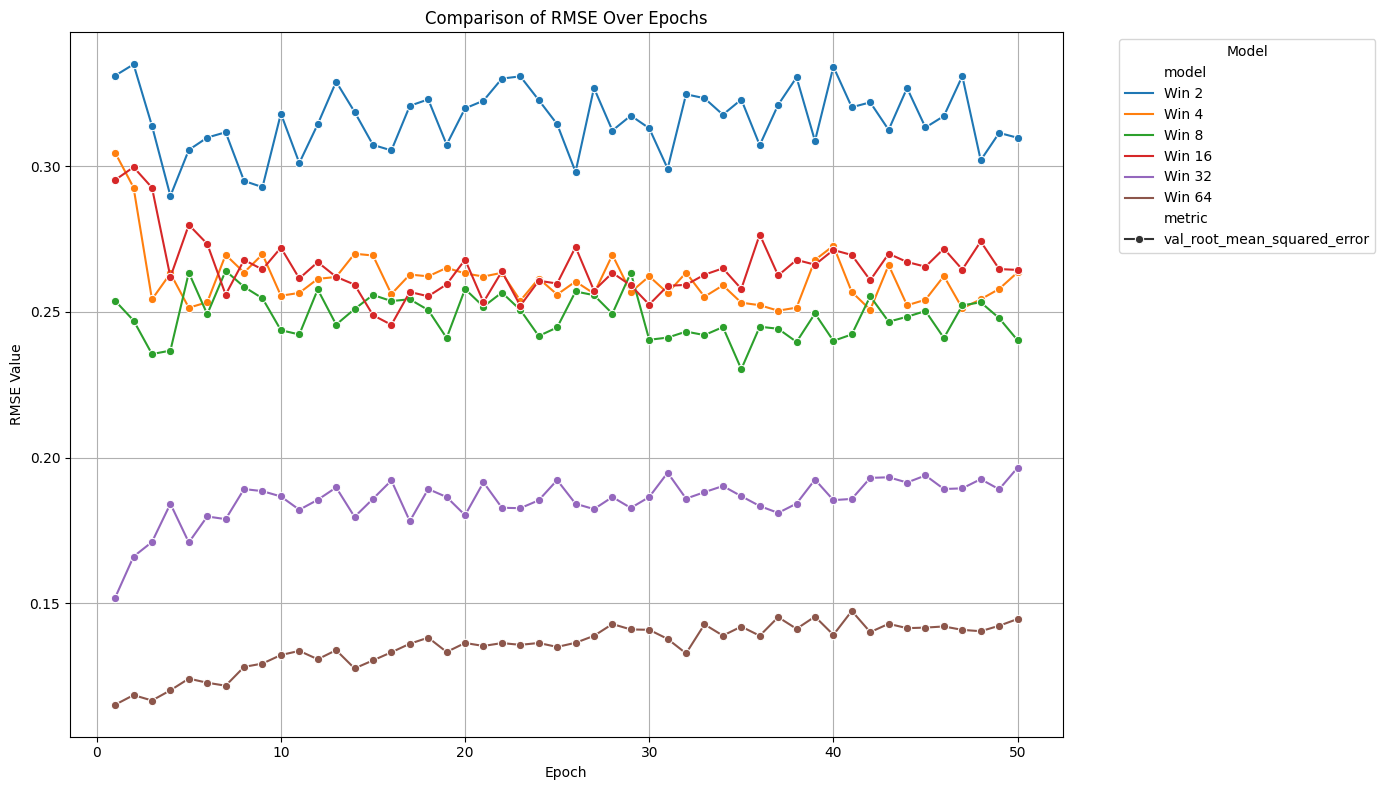

In [87]:
# Plot the RMSE comparison
plt.figure(figsize=(14, 8))
sns.lineplot(data=all_models, x='epoch', y='value', hue='model', style='metric', markers=True)

# Customize plot
plt.title('Comparison of RMSE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('RMSE Value')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

In [41]:
from Bio.SubsMat import MatrixInfo

ModuleNotFoundError: No module named 'Bio'

In [64]:
BLOSUM60 = {
'A':'4 -1 -1 -2  0 -1 -1  0 -2 -1 -1 -1 -1 -2 -1  1  0 -3 -2  0',
'R': '-1  5  0 -1 -3  1  0 -2  0 -3 -2  2 -1 -3 -2 -1 -1 -3 -2 -2',
'N': '-1  0  6  1 -2  0  0  0  1 -3 -3  0 -2 -3 -2  1  0 -4 -2 -3',
'D': '-2 -1  1  6 -3  0  2 -1 -1 -3 -3 -1 -3 -3 -1  0 -1 -4 -3 -3',
'C':' 0 -3 -2 -3  9 -3 -3 -2 -3 -1 -1 -3 -1 -2 -3 -1 -1 -2 -2 -1',
'Q': '-1  1  0  0 -3  5  2 -2  1 -3 -2  1  0 -3 -1  0 -1 -2 -1 -2',
'E': '-1  0  0  2 -3  2  5 -2  0 -3 -3  1 -2 -3 -1  0 -1 -3 -2 -2',
'G':  '0 -2  0 -1 -2 -2 -2  6 -2 -3 -4 -1 -2 -3 -2  0 -2 -2 -3 -3',
'H': '-2  0  1 -1 -3  1  0 -2  7 -3 -3 -1 -1 -1 -2 -1 -2 -2  2 -3',
'I': '-1 -3 -3 -3 -1 -3 -3 -3 -3  4  2 -3  1  0 -3 -2 -1 -2 -1  3',
'L': '-1 -2 -3 -3 -1 -2 -3 -4 -3  2  4 -2  2  0 -3 -2 -1 -2 -1  1',
'K': '-1  2  0 -1 -3  1  1 -1 -1 -3 -2  4 -1 -3 -1  0 -1 -3 -2 -2',
'M': '-1 -1 -2 -3 -1  0 -2 -2 -1  1  2 -1  5  0 -2 -1 -1 -1 -1  1',
'F': '-2 -3 -3 -3 -2 -3 -3 -3 -1  0  0 -3  0  6 -4 -2 -2  1  3 -1',
'P': '-1 -2 -2 -1 -3 -1 -1 -2 -2 -3 -3 -1 -2 -4  7 -1 -1 -4 -3 -2',
'S':  '1 -1  1  0 -1  0  0  0 -1 -2 -2  0 -1 -2 -1  4  1 -3 -2 -2',
'T':  '0 -1  0 -1 -1 -1 -1 -2 -2 -1 -1 -1 -1 -2 -1  1  4 -2 -2  0',
'W': '-3 -3 -4 -4 -2 -2 -3 -2 -2 -2 -2 -3 -1  1 -4 -3 -2 10  2 -3',
'Y': '-2 -2 -2 -3 -2 -1 -2 -3  2 -1 -1 -2 -1  3 -3 -2 -2  2  6 -1',
'V':  '0 -2 -3 -3 -1 -2 -2 -3 -3  3  1 -2  1 -1 -2 -2  0 -3 -1  4'

}
BLOSUM60

{'A': '4 -1 -1 -2  0 -1 -1  0 -2 -1 -1 -1 -1 -2 -1  1  0 -3 -2  0',
 'R': '-1  5  0 -1 -3  1  0 -2  0 -3 -2  2 -1 -3 -2 -1 -1 -3 -2 -2',
 'N': '-1  0  6  1 -2  0  0  0  1 -3 -3  0 -2 -3 -2  1  0 -4 -2 -3',
 'D': '-2 -1  1  6 -3  0  2 -1 -1 -3 -3 -1 -3 -3 -1  0 -1 -4 -3 -3',
 'C': ' 0 -3 -2 -3  9 -3 -3 -2 -3 -1 -1 -3 -1 -2 -3 -1 -1 -2 -2 -1',
 'Q': '-1  1  0  0 -3  5  2 -2  1 -3 -2  1  0 -3 -1  0 -1 -2 -1 -2',
 'E': '-1  0  0  2 -3  2  5 -2  0 -3 -3  1 -2 -3 -1  0 -1 -3 -2 -2',
 'G': '0 -2  0 -1 -2 -2 -2  6 -2 -3 -4 -1 -2 -3 -2  0 -2 -2 -3 -3',
 'H': '-2  0  1 -1 -3  1  0 -2  7 -3 -3 -1 -1 -1 -2 -1 -2 -2  2 -3',
 'I': '-1 -3 -3 -3 -1 -3 -3 -3 -3  4  2 -3  1  0 -3 -2 -1 -2 -1  3',
 'L': '-1 -2 -3 -3 -1 -2 -3 -4 -3  2  4 -2  2  0 -3 -2 -1 -2 -1  1',
 'K': '-1  2  0 -1 -3  1  1 -1 -1 -3 -2  4 -1 -3 -1  0 -1 -3 -2 -2',
 'M': '-1 -1 -2 -3 -1  0 -2 -2 -1  1  2 -1  5  0 -2 -1 -1 -1 -1  1',
 'F': '-2 -3 -3 -3 -2 -3 -3 -3 -1  0  0 -3  0  6 -4 -2 -2  1  3 -1',
 'P': '-1 -2 -2 -1 -3 -1 -1 -2 -2 -3

In [65]:
counter=1
for k in BLOSUM60.keys():
    print(f'"{k}":',[int(i) for i in BLOSUM60[k].split( )],',')
    BLOSUM60[k] = [int(i) for i in BLOSUM60[k].split( )]

    counter+=1

"A": [4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0] ,
"R": [-1, 5, 0, -1, -3, 1, 0, -2, 0, -3, -2, 2, -1, -3, -2, -1, -1, -3, -2, -2] ,
"N": [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3] ,
"D": [-2, -1, 1, 6, -3, 0, 2, -1, -1, -3, -3, -1, -3, -3, -1, 0, -1, -4, -3, -3] ,
"C": [0, -3, -2, -3, 9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1] ,
"Q": [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2] ,
"E": [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2] ,
"G": [0, -2, 0, -1, -2, -2, -2, 6, -2, -3, -4, -1, -2, -3, -2, 0, -2, -2, -3, -3] ,
"H": [-2, 0, 1, -1, -3, 1, 0, -2, 7, -3, -3, -1, -1, -1, -2, -1, -2, -2, 2, -3] ,
"I": [-1, -3, -3, -3, -1, -3, -3, -3, -3, 4, 2, -3, 1, 0, -3, -2, -1, -2, -1, 3] ,
"L": [-1, -2, -3, -3, -1, -2, -3, -4, -3, 2, 4, -2, 2, 0, -3, -2, -1, -2, -1, 1] ,
"K": [-1, 2, 0, -1, -3, 1, 1, -1, -1, -3, -2, 4, -1, -3, -1, 0, -1, -3, -2, -2] ,
"M": [-1, -1, -2

In [57]:
BLOSUM60['A'], len(BLOSUM60['A'])

([4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0],
 20)

In [66]:
{"A": [4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0] ,
"R": [-1, 5, 0, -1, -3, 1, 0, -2, 0, -3, -2, 2, -1, -3, -2, -1, -1, -3, -2, -2] ,
"N": [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3] ,
"D": [-2, -1, 1, 6, -3, 0, 2, -1, -1, -3, -3, -1, -3, -3, -1, 0, -1, -4, -3, -3] ,
"C": [0, -3, -2, -3, 9, -3, -3, -2, -3, -1, -1, -3, -1, -2, -3, -1, -1, -2, -2, -1] ,
"Q": [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2] ,
"E": [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2] ,
"G": [0, -2, 0, -1, -2, -2, -2, 6, -2, -3, -4, -1, -2, -3, -2, 0, -2, -2, -3, -3] ,
"H": [-2, 0, 1, -1, -3, 1, 0, -2, 7, -3, -3, -1, -1, -1, -2, -1, -2, -2, 2, -3] ,
"I": [-1, -3, -3, -3, -1, -3, -3, -3, -3, 4, 2, -3, 1, 0, -3, -2, -1, -2, -1, 3] ,
"L": [-1, -2, -3, -3, -1, -2, -3, -4, -3, 2, 4, -2, 2, 0, -3, -2, -1, -2, -1, 1] ,
"K": [-1, 2, 0, -1, -3, 1, 1, -1, -1, -3, -2, 4, -1, -3, -1, 0, -1, -3, -2, -2] ,
"M": [-1, -1, -2, -3, -1, 0, -2, -2, -1, 1, 2, -1, 5, 0, -2, -1, -1, -1, -1, 1] ,
"F": [-2, -3, -3, -3, -2, -3, -3, -3, -1, 0, 0, -3, 0, 6, -4, -2, -2, 1, 3, -1] ,
"P": [-1, -2, -2, -1, -3, -1, -1, -2, -2, -3, -3, -1, -2, -4, 7, -1, -1, -4, -3, -2] ,
"S": [1, -1, 1, 0, -1, 0, 0, 0, -1, -2, -2, 0, -1, -2, -1, 4, 1, -3, -2, -2] ,
"T": [0, -1, 0, -1, -1, -1, -1, -2, -2, -1, -1, -1, -1, -2, -1, 1, 4, -2, -2, 0] ,
"W": [-3, -3, -4, -4, -2, -2, -3, -2, -2, -2, -2, -3, -1, 1, -4, -3, -2, 10, 2, -3] ,
"Y": [-2, -2, -2, -3, -2, -1, -2, -3, 2, -1, -1, -2, -1, 3, -3, -2, -2, 2, 6, -1] ,
"V": [0, -2, -3, -3, -1, -2, -2, -3, -3, 3, 1, -2, 1, -1, -2, -2, 0, -3, -1, 4] }

{'A': [4,
  -1,
  -1,
  -2,
  0,
  -1,
  -1,
  0,
  -2,
  -1,
  -1,
  -1,
  -1,
  -2,
  -1,
  1,
  0,
  -3,
  -2,
  0],
 'R': [-1,
  5,
  0,
  -1,
  -3,
  1,
  0,
  -2,
  0,
  -3,
  -2,
  2,
  -1,
  -3,
  -2,
  -1,
  -1,
  -3,
  -2,
  -2],
 'N': [-1, 0, 6, 1, -2, 0, 0, 0, 1, -3, -3, 0, -2, -3, -2, 1, 0, -4, -2, -3],
 'D': [-2,
  -1,
  1,
  6,
  -3,
  0,
  2,
  -1,
  -1,
  -3,
  -3,
  -1,
  -3,
  -3,
  -1,
  0,
  -1,
  -4,
  -3,
  -3],
 'C': [0,
  -3,
  -2,
  -3,
  9,
  -3,
  -3,
  -2,
  -3,
  -1,
  -1,
  -3,
  -1,
  -2,
  -3,
  -1,
  -1,
  -2,
  -2,
  -1],
 'Q': [-1, 1, 0, 0, -3, 5, 2, -2, 1, -3, -2, 1, 0, -3, -1, 0, -1, -2, -1, -2],
 'E': [-1, 0, 0, 2, -3, 2, 5, -2, 0, -3, -3, 1, -2, -3, -1, 0, -1, -3, -2, -2],
 'G': [0,
  -2,
  0,
  -1,
  -2,
  -2,
  -2,
  6,
  -2,
  -3,
  -4,
  -1,
  -2,
  -3,
  -2,
  0,
  -2,
  -2,
  -3,
  -3],
 'H': [-2,
  0,
  1,
  -1,
  -3,
  1,
  0,
  -2,
  7,
  -3,
  -3,
  -1,
  -1,
  -1,
  -2,
  -1,
  -2,
  -2,
  2,
  -3],
 'I': [-1,
  -3,
  -3,
  -3,
  -1,
 

In [76]:
BLOSUM60[three_to_one['ALA']]

[4, -1, -1, -2, 0, -1, -1, 0, -2, -1, -1, -1, -1, -2, -1, 1, 0, -3, -2, 0]

In [75]:
three_to_one = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N',
    'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V',
    'TRP': 'W', 'TYR': 'Y'
}
